In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.21.0
NumPy Version: 2.2.6


In [3]:
DATASET_PATH = Path("../datasets/processed")

TRAIN_PATH = DATASET_PATH / "train"
VALIDATION_PATH = DATASET_PATH / "validation"
TEST_PATH = DATASET_PATH / "test"

print(TRAIN_PATH)
print(VALIDATION_PATH)
print(TEST_PATH)

../datasets/processed/train
../datasets/processed/validation
../datasets/processed/test


In [4]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 7034 files belonging to 2 classes.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 879 files belonging to 2 classes.


In [9]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 880 files belonging to 2 classes.


In [10]:
class_names = train_dataset.class_names

print(class_names)

['Gemstone', 'NotGem']


In [11]:
print("Training batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Test batches:", len(test_dataset))

Training batches: 220
Validation batches: 28
Test batches: 28


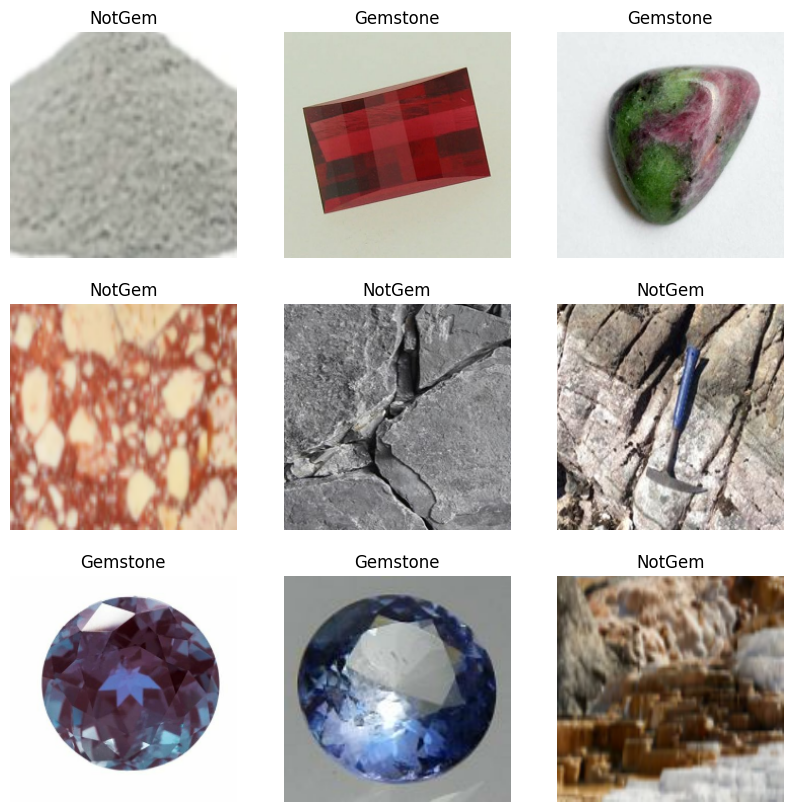

In [12]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [13]:
# ==========================================================
# Optimize TensorFlow Data Pipeline
# ==========================================================
#
# TensorFlow loads images from disk during training.
# Reading images from disk every epoch is relatively slow.
#
# To improve training performance, we use:
#
# 1. cache()
#    - Stores the dataset in memory after the first epoch.
#    - Eliminates repeated disk reads.
#
# 2. shuffle()
#    - Randomly rearranges the training images.
#    - Prevents the model from learning patterns based on
#      image order.
#
# 3. prefetch()
#    - Loads the next batch while the GPU/CPU processes
#      the current batch.
#    - Reduces idle time and speeds up training.
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

print("Dataset optimization completed successfully.")

Dataset optimization completed successfully.


In [14]:
# ==========================================================
# Data Augmentation
# ==========================================================
#
# Deep learning models generally perform better when they
# are exposed to more image variations during training.
#
# Instead of collecting thousands of additional gemstone
# images, TensorFlow generates new variations in real time.
#
# The original dataset stored on disk is NOT modified.
# Augmentation is applied only while training.
#
# Transformations used:
#
# RandomFlip
#     - Horizontally flips images.
#
# RandomRotation
#     - Rotates images slightly.
#
# RandomZoom
#     - Randomly zooms into images.
#
# RandomContrast
#     - Simulates different lighting conditions.
#
# These augmentations help the model generalize better to
# unseen gemstone images uploaded by users.
# ==========================================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.10),

    tf.keras.layers.RandomZoom(0.10),

    tf.keras.layers.RandomContrast(0.10)

])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


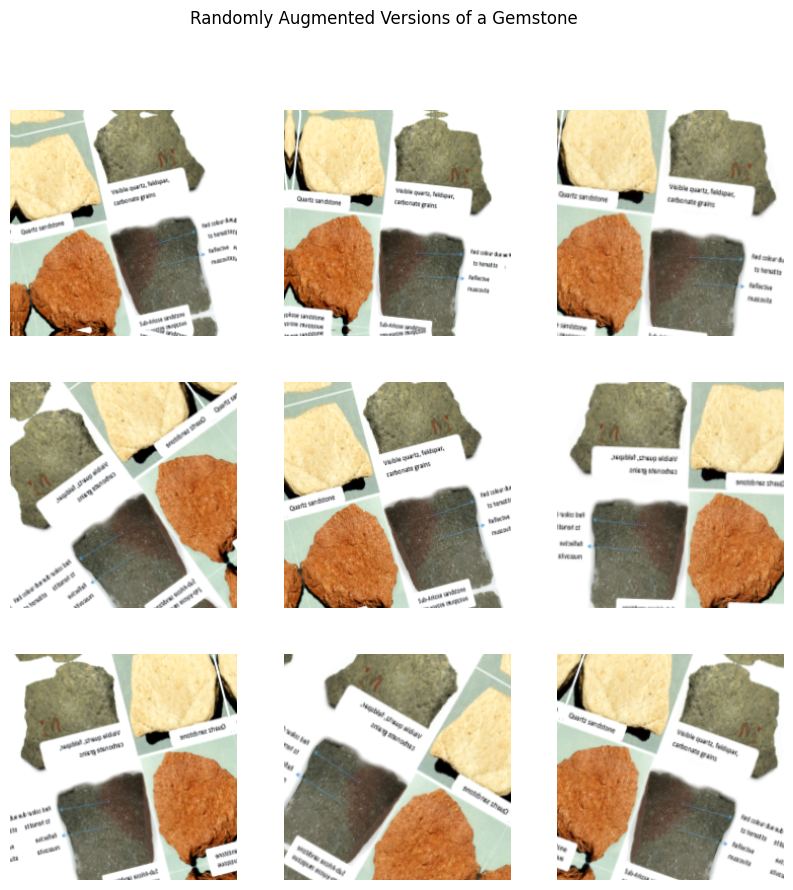

In [15]:
# ==========================================================
# Visualize Data Augmentation
# ==========================================================
#
# Before training the model, it is good practice to inspect
# the augmented images.
#
# This allows us to verify that:
#
# • Images remain realistic.
# • Augmentations are not too aggressive.
# • Gemstones are still recognizable.
#
# Here we select a single gemstone image and apply the
# augmentation pipeline multiple times.
#
# Each output should look slightly different while
# preserving the gemstone's important visual features.
# ==========================================================

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    first_image = images[0]

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0)
        )

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.suptitle("Randomly Augmented Versions of a Gemstone")

plt.show()

In [16]:
# ==========================================================
# Load the Pre-trained EfficientNetB0 Model
# ==========================================================
#
# Instead of training a Convolutional Neural Network (CNN)
# from scratch, we use Transfer Learning.
#
# Transfer Learning allows us to reuse knowledge learned
# from a very large dataset (ImageNet), which contains
# over 14 million images across 1,000 different classes.
#
# Advantages:
#
# • Faster training
# • Higher accuracy
# • Less data required
# • Better generalization
#
# We exclude the original classification layer because
# our task is binary classification:
#
#     Gemstone
#     NotGem
#
# include_top=False
#     Removes ImageNet's original classifier.
#
# weights="imagenet"
#     Loads Google's pre-trained weights.
#
# input_shape=(224,224,3)
#     Matches the image size used throughout the project.
#
# ==========================================================

base_model = tf.keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224, 224, 3)

)

print("EfficientNetB0 loaded successfully.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
EfficientNetB0 loaded successfully.


In [17]:
# ==========================================================
# Freeze the Base Model
# ==========================================================
#
# EfficientNetB0 already contains millions of learned
# parameters from ImageNet.
#
# Initially, we freeze all convolutional layers so that
# these learned features are preserved.
#
# During the first training phase, only our custom
# classification head will learn.
#
# This approach:
#
# • Prevents overfitting
# • Speeds up training
# • Produces better results on small datasets
#
# Later, we can unfreeze some layers for fine-tuning.
# ==========================================================

base_model.trainable = False

print("Base model frozen.")

Base model frozen.


In [18]:
# ==========================================================
# Build the Complete Classification Model
# ==========================================================
#
# The model architecture consists of:
#
# Input Image
#        │
#        ▼
# Data Augmentation
#        │
#        ▼
# EfficientNetB0
#        │
#        ▼
# Global Average Pooling
#        │
#        ▼
# Dropout
#        │
#        ▼
# Dense (1 neuron)
#        │
#        ▼
# Sigmoid Activation
#
# Layer explanations:
#
# Data Augmentation
#     Generates new image variations during training.
#
# Rescaling
#     Converts pixel values from [0,255] to [0,1].
#
# EfficientNetB0
#     Extracts high-level image features.
#
# GlobalAveragePooling2D
#     Reduces feature maps into a feature vector.
#
# Dropout
#     Randomly disables neurons during training to reduce
#     overfitting.
#
# Dense(1)
#     Outputs a single probability for binary
#     classification.
#
# Sigmoid
#     Converts the output into a probability between
#     0 and 1.
#
# ==========================================================

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.layers.Rescaling(1.0 / 255)(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
# ==========================================================
# Compile the Model
# ==========================================================
#
# Before training, TensorFlow requires:
#
# Optimizer
#     Updates the model's weights.
#
# Loss Function
#     Measures prediction error.
#
# Metrics
#     Evaluates training performance.
#
# Optimizer:
#     Adam
#
# Adam combines the advantages of momentum and adaptive
# learning rates, making it one of the most widely used
# optimizers for deep learning.
#
# Learning Rate:
#     0.0001
#
# A relatively small learning rate is used because the
# model already contains pre-trained ImageNet weights.
#
# Loss Function:
#     BinaryCrossentropy
#
# Since our problem has only two classes
# (Gemstone / NotGem), binary cross-entropy is the
# appropriate loss function.
#
# Metric:
#     Accuracy
#
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        "accuracy"
    ]

)

print("Model compiled successfully.")

Model compiled successfully.


In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
# ==========================================================
# Create Training Callbacks
# ==========================================================
#
# Callbacks allow TensorFlow to automatically perform
# useful actions during training.
#
# In this project we use three callbacks:
#
# 1. EarlyStopping
#    - Stops training when validation loss no longer
#      improves.
#    - Prevents overfitting.
#    - Restores the best-performing model weights.
#
# 2. ModelCheckpoint
#    - Saves the best model during training.
#    - The best model will later be used for prediction.
#
# 3. ReduceLROnPlateau
#    - Automatically reduces the learning rate when
#      validation loss stops improving.
#    - Helps the optimizer converge more effectively.
# ==========================================================

from pathlib import Path

# Create models directory if it doesn't already exist
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True,

        verbose=1

    ),

    tf.keras.callbacks.ModelCheckpoint(

        filepath=MODEL_DIR / "best_gem_detector.keras",

        monitor="val_loss",

        save_best_only=True,

        verbose=1

    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.2,

        patience=3,

        min_lr=1e-7,

        verbose=1

    )

]

print("Callbacks created successfully.")

Callbacks created successfully.


In [23]:
# ==========================================================
# Train the Model
# ==========================================================
#
# The model learns by repeatedly processing the training
# dataset over multiple epochs.
#
# During each epoch:
#
# 1. Images are loaded.
# 2. Data augmentation is applied.
# 3. EfficientNet extracts image features.
# 4. The classifier predicts the class.
# 5. The loss is calculated.
# 6. Model weights are updated.
#
# Validation is performed after each epoch using images
# the model has never seen during training.
#
# Callbacks monitor training progress and automatically
# stop training or save the best model when appropriate.
# ==========================================================

EPOCHS = 20

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS,

    callbacks=callbacks

)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.5000 - loss: 0.7110
Epoch 1: val_loss improved from None to 0.69326, saving model to ../models/best_gem_detector.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 90s 393ms/step - accuracy: 0.4932 - loss: 0.7017 - val_accuracy: 0.4994 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.4957 - loss: 0.6967
Epoch 2: val_loss did not improve from 0.69326
220/220 ━━━━━━━━━━━━━━━━━━━━ 92s 418ms/step - accuracy: 0.4956 - loss: 0.6961 - val_accuracy: 0.4994 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.5102 - loss: 0.6947
Epoch 3: val_loss did not improve from 0.69326
220/220 ━━━━━━━━━━━━━━━━━━━━ 88s 400ms/step - accuracy: 0.5007 - loss: 0.6951 - val_accuracy: 0.4994 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.5036 - loss: 0.6961
Epoch 4: va

In [25]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels.numpy()[:20])

(32, 224, 224, 3)
(32,)
[0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 0]


In [26]:
print(images.dtype)
print(images.numpy().min())
print(images.numpy().max())

<dtype: 'float32'>
0.0
255.0


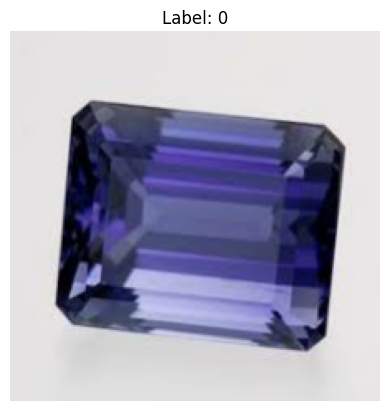

In [27]:
import matplotlib.pyplot as plt

plt.imshow(images[0].numpy().astype("uint8"))
plt.title(f"Label: {labels[0].numpy()}")
plt.axis("off")
plt.show()

In [28]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [29]:
from collections import Counter

train_counts = Counter()

for _, labels in train_dataset:
    train_counts.update(labels.numpy())

print(train_counts)

Counter({np.int32(0): 3520, np.int32(1): 3514})


In [30]:
predictions = model.predict(images)

print(predictions[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.49784297]
 [0.49798432]
 [0.49739528]
 [0.498397  ]
 [0.49788237]
 [0.49797142]
 [0.4980719 ]
 [0.49804428]
 [0.49778903]
 [0.49783227]
 [0.49794018]
 [0.4976483 ]
 [0.49795526]
 [0.49821946]
 [0.49776477]
 [0.49780953]
 [0.49770784]
 [0.49759546]
 [0.49801174]
 [0.49815565]]


In [31]:
weights = model.layers[-1].get_weights()

print(weights[0].shape)   # Weight matrix
print(weights[1])         # Bias

(1280, 1)
[-0.00381536]


In [32]:
feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.output
)

features = feature_extractor(images)

print(features.shape)
print(features.numpy().std())

(32, 7, 7, 1280)
0.77999496


In [33]:
fresh_train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=32,
    shuffle=False
)

print(fresh_train_dataset.class_names)

Found 7034 files belonging to 2 classes.
['Gemstone', 'NotGem']


In [34]:
model.layers[3].trainable

False

In [35]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)